# Data Exploration and Fill Strategy Comparison

This notebook explores the raw measured demand dataset alongside the datasets processed with linear and seasonal fill strategies.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Define file paths (relative to this notebook's directory)
raw_path = '../../data/forecasting/raw_data_measured_demand.csv'
linear_path = '../../data/forecasting/data_filled_linear.csv'
seasonal_path = '../../data/forecasting/data_filled_seasonal.csv'

# Load the datasets
raw_data = pd.read_csv(raw_path, parse_dates=['Time Point'], index_col='Time Point')
linear_filled = pd.read_csv(linear_path, parse_dates=['timestamp'], index_col='timestamp')
seasonal_filled = pd.read_csv(seasonal_path, parse_dates=['timestamp'], index_col='timestamp')

# Convert all index timestamps to UTC to avoid Matplotlib plotting warnings
raw_data.index = pd.to_datetime(raw_data.index, utc=True)
linear_filled.index = pd.to_datetime(linear_filled.index, utc=True)
seasonal_filled.index = pd.to_datetime(seasonal_filled.index, utc=True)


## Analyze Missing Values

Calculate and print the number of missing values for the raw dataset and the imputed datasets to verify the filling process.

In [7]:
print("Number of missing values in RAW data:", raw_data.isna().sum().values[0])
print("Number of missing values in LINEAR filled data:", linear_filled.isna().sum().values[0])
print("Number of missing values in SEASONAL filled data:", seasonal_filled.isna().sum().values[0])

Number of missing values in RAW data: 2769
Number of missing values in LINEAR filled data: 0
Number of missing values in SEASONAL filled data: 0


## Visualizing the Gaps

Let's visualize the raw dataset on its own to clearly identify where the measurements are missing.

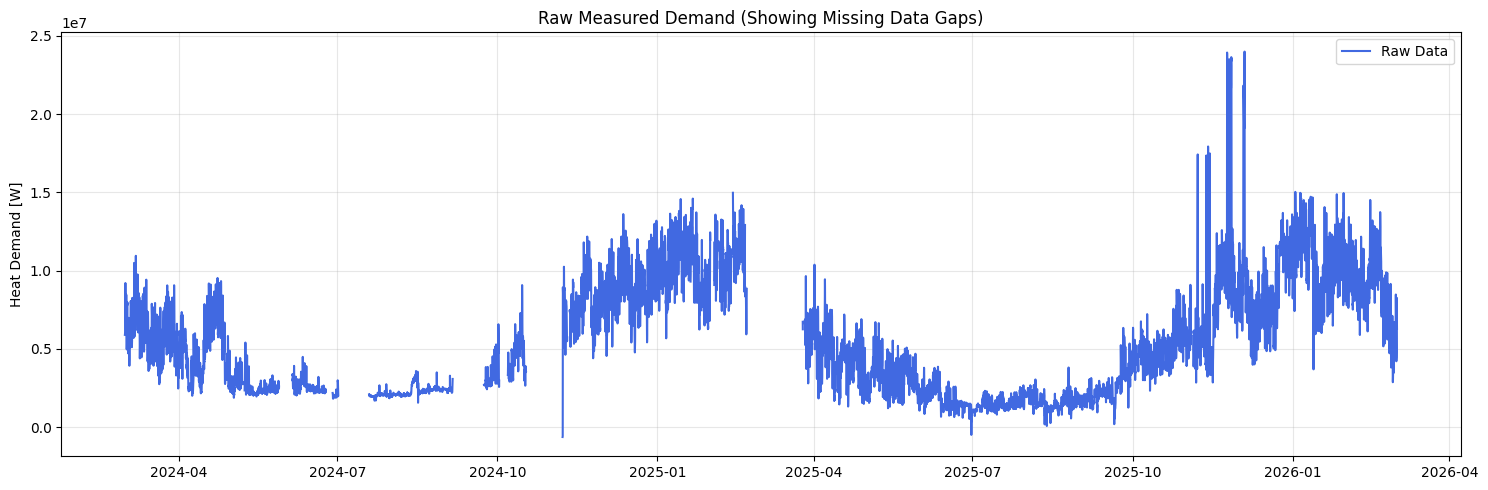

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(raw_data.index, raw_data.iloc[:, 0], label='Raw Data', color='royalblue')
plt.title('Raw Measured Demand (Showing Missing Data Gaps)')
plt.ylabel('Heat Demand [W]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Comparing the Filling Algorithms

To see how the two filling strategies operated on the missing periods, we can plot the filled datasets and overlay the raw dataset on top.

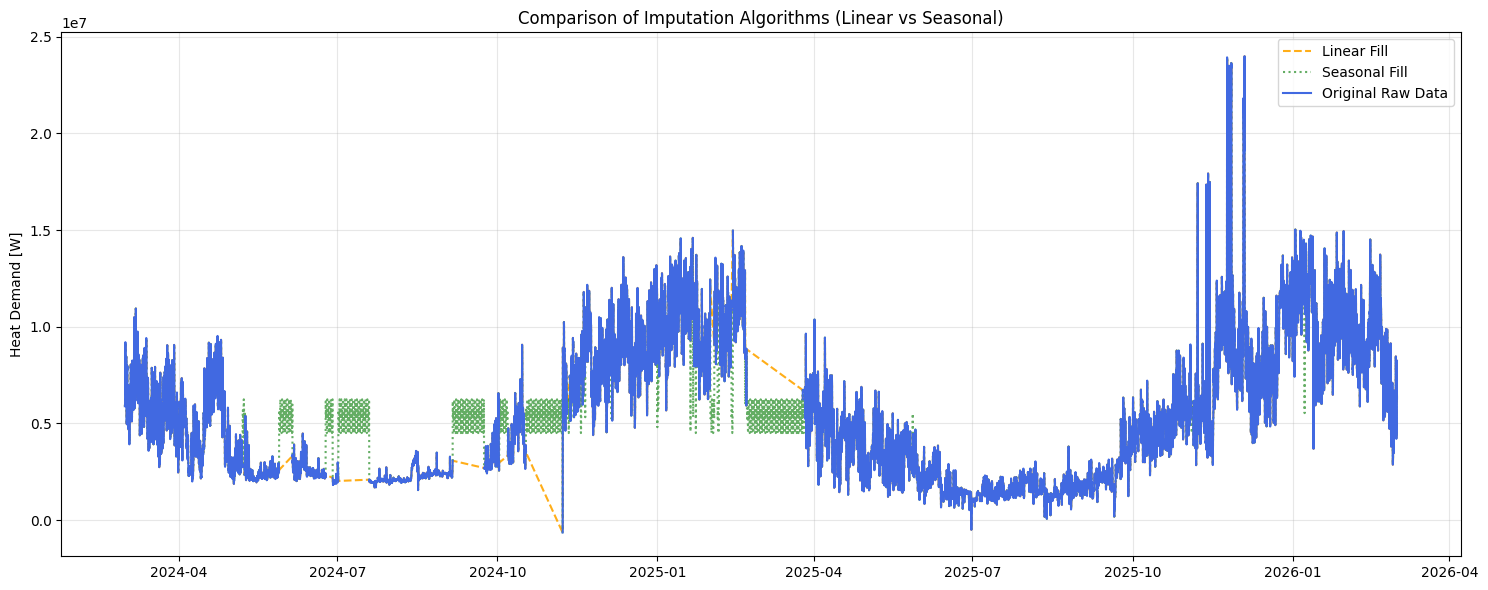

In [9]:
plt.figure(figsize=(15, 6))

# Plot the filled areas first
plt.plot(linear_filled.index, linear_filled.iloc[:, 0], label='Linear Fill', color='orange', alpha=0.9, linestyle='--')
plt.plot(seasonal_filled.index, seasonal_filled.iloc[:, 0], label='Seasonal Fill', color='forestgreen', alpha=0.7, linestyle=':')

# Plot the raw data on top so original points are clearly visible
plt.plot(raw_data.index, raw_data.iloc[:, 0], label='Original Raw Data', color='royalblue', linewidth=1.5)

plt.title('Comparison of Imputation Algorithms (Linear vs Seasonal)')
plt.ylabel('Heat Demand [W]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Zoomed-in Analysis of Interpolation Differences

Apply a tight date-range constraint using xlim to zoom into specific weeks, revealing the micro-level differences between seasonal and linear interpolation.

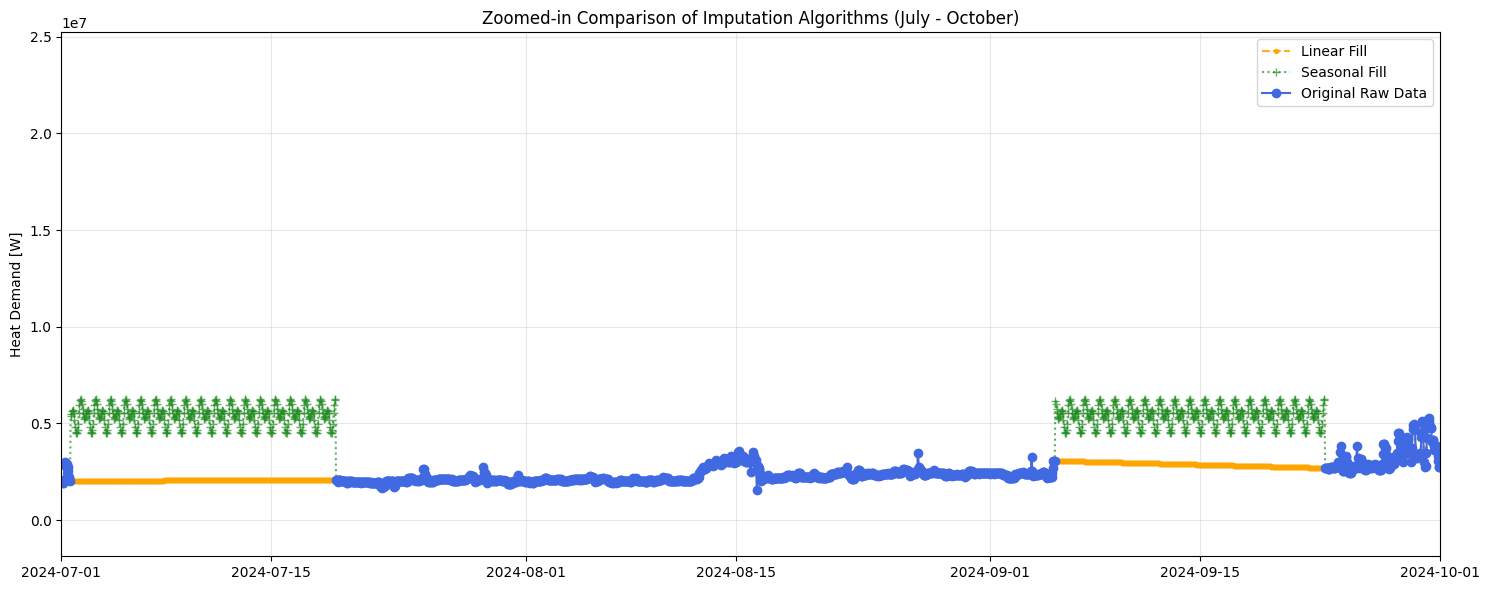

In [12]:
plt.figure(figsize=(15, 6))

plt.plot(linear_filled.index, linear_filled.iloc[:, 0], label='Linear Fill', color='orange', alpha=0.9, linestyle='--', marker='.')
plt.plot(seasonal_filled.index, seasonal_filled.iloc[:, 0], label='Seasonal Fill', color='forestgreen', alpha=0.7, linestyle=':', marker='+')
plt.plot(raw_data.index, raw_data.iloc[:, 0], label='Original Raw Data', color='royalblue', linewidth=1.5, marker='o')

plt.xlim(pd.Timestamp('2024-07-01'), pd.Timestamp('2024-10-01'))

plt.title('Zoomed-in Comparison of Imputation Algorithms (July - October)')
plt.ylabel('Heat Demand [W]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

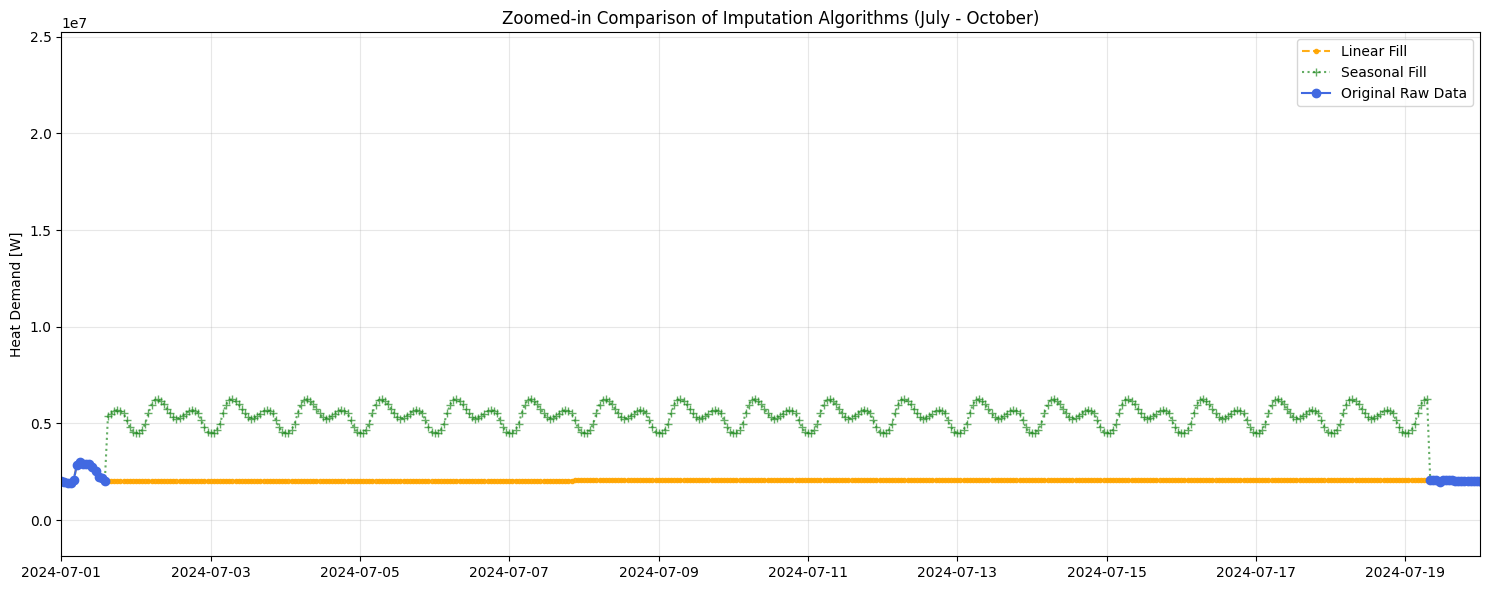

In [13]:
plt.figure(figsize=(15, 6))

plt.plot(linear_filled.index, linear_filled.iloc[:, 0], label='Linear Fill', color='orange', alpha=0.9, linestyle='--', marker='.')
plt.plot(seasonal_filled.index, seasonal_filled.iloc[:, 0], label='Seasonal Fill', color='forestgreen', alpha=0.7, linestyle=':', marker='+')
plt.plot(raw_data.index, raw_data.iloc[:, 0], label='Original Raw Data', color='royalblue', linewidth=1.5, marker='o')

plt.xlim(pd.Timestamp('2024-07-01'), pd.Timestamp('2024-7-20'))

plt.title('Zoomed-in Comparison of Imputation Algorithms (July - October)')
plt.ylabel('Heat Demand [W]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()